# Supply Chain GHG Emission Factors — Feasibility Checkpoint

## Dataset

**Source:** U.S. EPA Supply Chain Greenhouse Gas Emission Factors (USEEIO model)  
**Link:** https://www.epa.gov/climateleadership/supply-chain-ghg-emission-factors-us-commodities-and-industries  

The EPA publishes industry-level GHG emission factors derived from its USEEIO input-output model. Each row maps a 2017 NAICS industry code to a supply-chain emission factor expressed in **kg CO2-equivalent emitted per USD of economic output** (purchaser price).

### Files used

| File | Description |
|---|---|
| `SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv` | All GHGs collapsed to CO₂e, 2021 USD baseline |
| `SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv` | Same structure, updated to 2022 USD baseline |
| `SupplyChainGHGEmissionFactors_v1.3.0_NAICS_byGHG_USD2022.csv` | Broken out by individual GHG (18 gases × 1016 industries) |

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110

## 1. Load the Data

In [5]:
DATA = "datasets/"

v21   = pd.read_csv(DATA + "SupplyChainGHGEmissionFactors_v1.2_NAICS_CO2e_USD2021.csv")
v22   = pd.read_csv(DATA + "SupplyChainGHGEmissionFactors_v1.3.0_NAICS_CO2e_USD2022.csv")
byghg = pd.read_csv(DATA + "SupplyChainGHGEmissionFactors_v1.3.0_NAICS_byGHG_USD2022.csv")

RENAME = {
    "2017 NAICS Code": "naics_code",
    "2017 NAICS Title": "industry",
    "GHG": "ghg",
    "Unit": "unit",
    "Supply Chain Emission Factors without Margins": "ef_no_margin",
    "Margins of Supply Chain Emission Factors": "ef_margin",
    "Supply Chain Emission Factors with Margins": "ef_with_margin",
    "Reference USEEIO Code": "useeio_code",
}
v21   = v21.rename(columns=RENAME)
v22   = v22.rename(columns=RENAME)
byghg = byghg.rename(columns=RENAME)

print(f"v1.2 (2021 USD): {v21.shape[0]:,} rows x {v21.shape[1]} cols")
print(f"v1.3 (2022 USD): {v22.shape[0]:,} rows x {v22.shape[1]} cols")
print(f"v1.3 by-GHG:     {byghg.shape[0]:,} rows x {byghg.shape[1]} cols")

v1.2 (2021 USD): 1,016 rows x 8 cols
v1.3 (2022 USD): 1,016 rows x 8 cols
v1.3 by-GHG:     18,288 rows x 8 cols


### First few rows — CO₂e file (2022 USD)

In [6]:
v22.head(10)

,naics_code,industry,ghg,unit,ef_no_margin,ef_margin,ef_with_margin,useeio_code
0,111110,Soybean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
1,111120,Oilseed (except Soybean) Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.488,0.044,0.532,1111A0
2,111130,Dry Pea and Bean Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
3,111140,Wheat Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
4,111150,Corn Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
5,111160,Rice Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
6,111191,Oilseed and Grain Combination Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
7,111199,All Other Grain Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.809,0.040,0.848,1111B0
8,111211,Potato Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200
9,111219,Other Vegetable (except Potato) and Melon Farming,All GHGs,"kg CO2e/2022 USD, purchaser price",0.591,0.041,0.631,111200


### First few rows — by-GHG file

In [7]:
byghg.head(10)

,naics_code,industry,ghg,unit,ef_no_margin,ef_margin,ef_with_margin,useeio_code
0,111110,Soybean Farming,HFC-23,"kg/2022 USD, purchaser price",3.230000e-09,1.340000e-09,4.570000e-09,1111A0
1,111110,Soybean Farming,Carbon dioxide,"kg/2022 USD, purchaser price",1.340000e-01,3.780000e-02,1.720000e-01,1111A0
2,111110,Soybean Farming,HFC-236fa,"kg/2022 USD, purchaser price",1.440000e-10,2.020000e-10,3.450000e-10,1111A0
3,111110,Soybean Farming,Carbon tetrafluoride,"kg/2022 USD, purchaser price",5.130000e-09,5.970000e-09,1.110000e-08,1111A0
4,111110,Soybean Farming,HFC-32,"kg/2022 USD, purchaser price",3.000000e-08,4.200000e-08,7.200000e-08,1111A0
5,111110,Soybean Farming,Hexafluoroethane,"kg/2022 USD, purchaser price",5.420000e-10,1.510000e-09,2.050000e-09,1111A0
6,111110,Soybean Farming,"HFCs and PFCs, unspecified","kg CO2e/2022 USD, purchaser price",3.580000e-04,4.860000e-04,8.440000e-04,1111A0
7,111110,Soybean Farming,HFC-125,"kg/2022 USD, purchaser price",4.560000e-08,6.190000e-08,1.080000e-07,1111A0
8,111110,Soybean Farming,Methane,"kg/2022 USD, purchaser price",3.310000e-04,1.510000e-04,4.820000e-04,1111A0
9,111110,Soybean Farming,HFC-134a,"kg/2022 USD, purchaser price",7.480000e-08,1.010000e-07,1.760000e-07,1111A0


### Summary statistics (2022 USD CO₂e)

In [8]:
v22[["ef_no_margin", "ef_margin", "ef_with_margin"]].describe().round(4)

,ef_no_margin,ef_margin,ef_with_margin
count,1016.0000,1016.0000,1016.0000
mean,0.2650,0.0169,0.2819
std,0.3148,0.0234,0.3214
min,0.0260,0.0000,0.0290
25%,0.1030,0.0000,0.1080
50%,0.1590,0.0000,0.1730
75%,0.3022,0.0302,0.3293
max,3.8460,0.1250,3.9240


## 2. Visualizations

### 2a. Distribution of emission factors

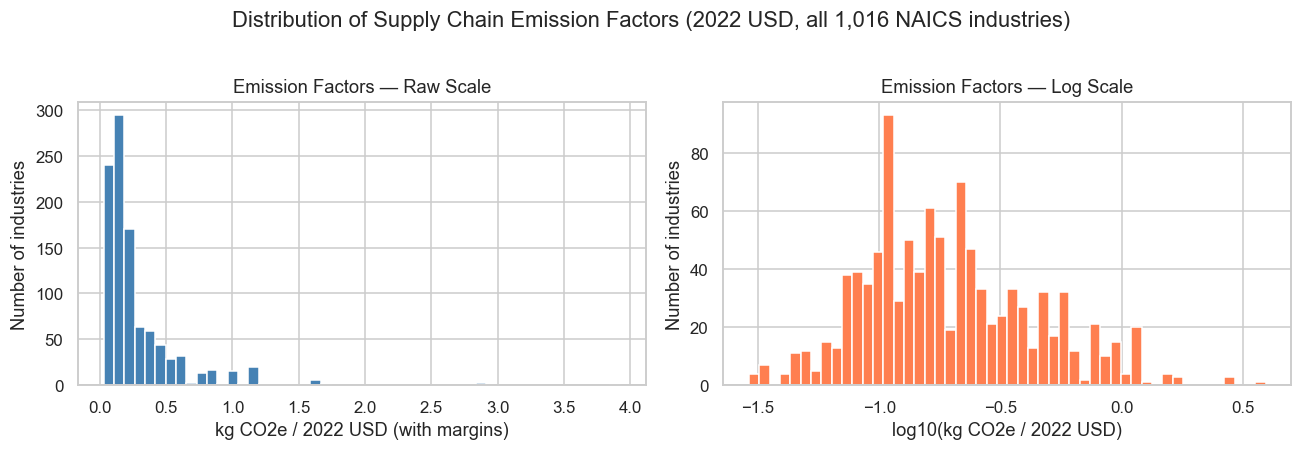

Range:  0.029 - 3.924 kg CO2e/USD
Median: 0.173   Mean: 0.282


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(v22["ef_with_margin"], bins=50, color="steelblue", edgecolor="white")
axes[0].set_xlabel("kg CO2e / 2022 USD (with margins)")
axes[0].set_ylabel("Number of industries")
axes[0].set_title("Emission Factors — Raw Scale")

log_ef = np.log10(v22["ef_with_margin"])
axes[1].hist(log_ef, bins=50, color="coral", edgecolor="white")
axes[1].set_xlabel("log10(kg CO2e / 2022 USD)")
axes[1].set_ylabel("Number of industries")
axes[1].set_title("Emission Factors — Log Scale")

plt.suptitle("Distribution of Supply Chain Emission Factors (2022 USD, all 1,016 NAICS industries)", y=1.02)
plt.tight_layout()
plt.show()

print(f"Range:  {v22['ef_with_margin'].min():.3f} - {v22['ef_with_margin'].max():.3f} kg CO2e/USD")
print(f"Median: {v22['ef_with_margin'].median():.3f}   Mean: {v22['ef_with_margin'].mean():.3f}")

### 2b. Top 15 most carbon-intensive industries

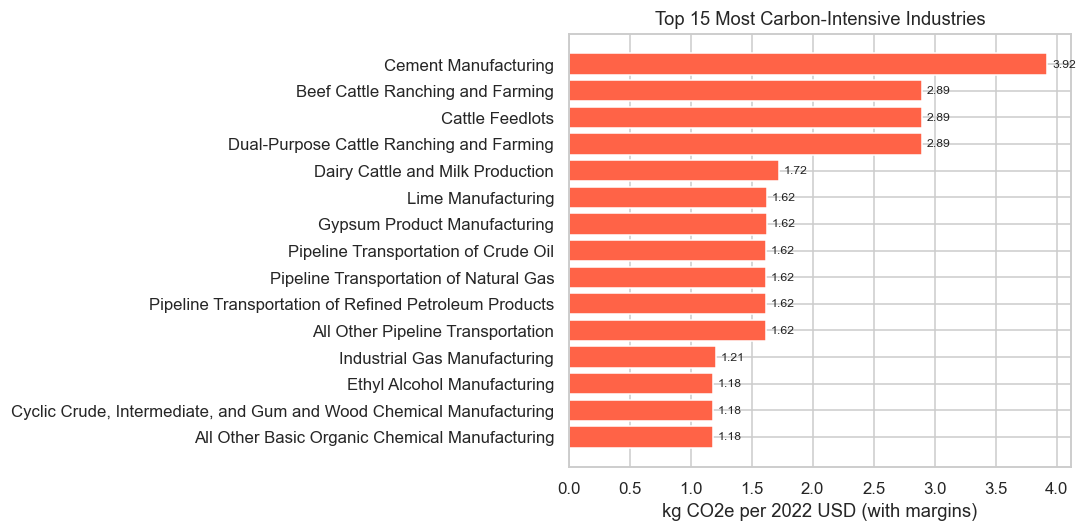

In [10]:
top15 = v22.nlargest(15, "ef_with_margin")[["industry", "ef_with_margin"]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top15["industry"][::-1], top15["ef_with_margin"][::-1], color="tomato")
ax.set_xlabel("kg CO2e per 2022 USD (with margins)")
ax.set_title("Top 15 Most Carbon-Intensive Industries")
ax.bar_label(bars, fmt="%.2f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

### 2c. Bottom 15 — least carbon-intensive industries

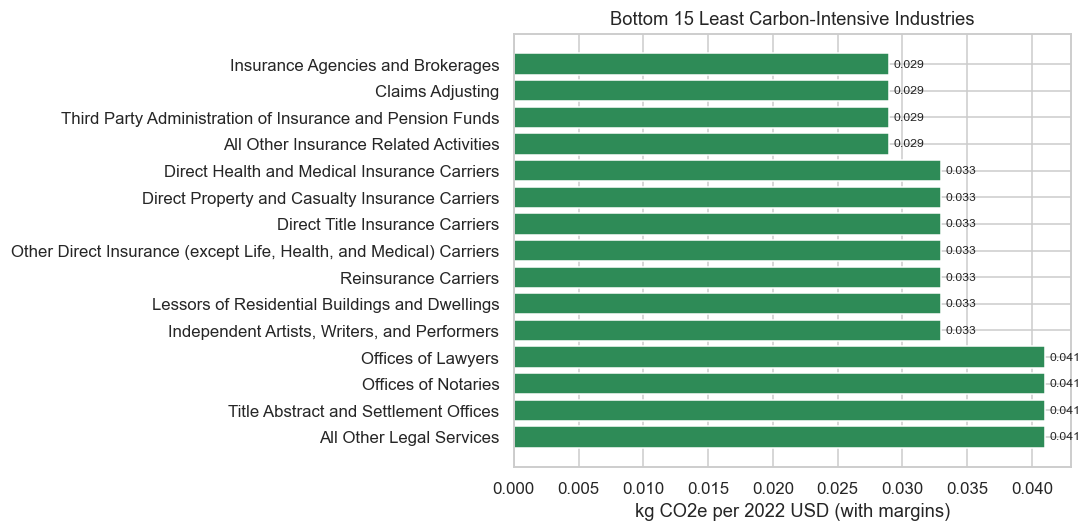

In [11]:
bot15 = v22.nsmallest(15, "ef_with_margin")[["industry", "ef_with_margin"]].reset_index(drop=True)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(bot15["industry"][::-1], bot15["ef_with_margin"][::-1], color="seagreen")
ax.set_xlabel("kg CO2e per 2022 USD (with margins)")
ax.set_title("Bottom 15 Least Carbon-Intensive Industries")
ax.bar_label(bars, fmt="%.3f", padding=3, fontsize=8)
plt.tight_layout()
plt.show()

### 2d. 2021 vs 2022 USD baseline — how did factors change?

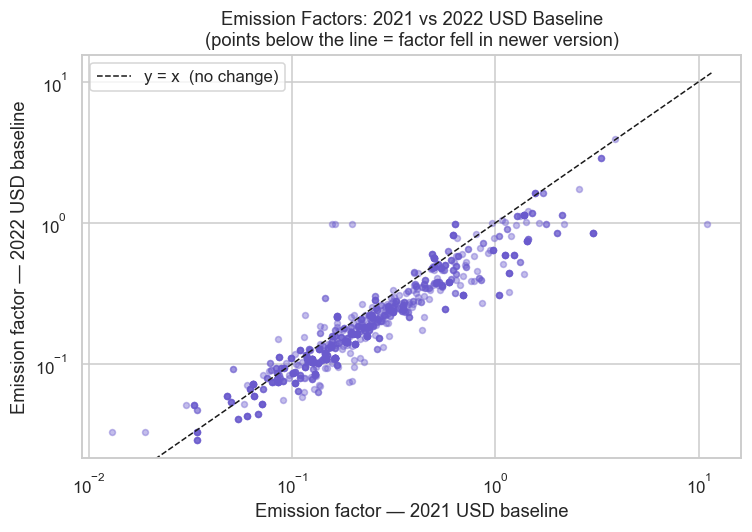

Median % change 2021 to 2022: -18.0%
IQR: -29.0% to -7.3%


In [12]:
compare = v21[["naics_code", "industry", "ef_with_margin"]].merge(
    v22[["naics_code", "ef_with_margin"]],
    on="naics_code",
    suffixes=("_2021", "_2022"),
)
compare["pct_change"] = (
    (compare["ef_with_margin_2022"] - compare["ef_with_margin_2021"])
    / compare["ef_with_margin_2021"] * 100
)

fig, ax = plt.subplots(figsize=(7, 5))
ax.scatter(compare["ef_with_margin_2021"], compare["ef_with_margin_2022"],
           alpha=0.4, s=15, color="slateblue")
lim = max(compare["ef_with_margin_2021"].max(), compare["ef_with_margin_2022"].max()) * 1.05
ax.plot([0, lim], [0, lim], "k--", lw=1, label="y = x  (no change)")
ax.set_xlabel("Emission factor — 2021 USD baseline")
ax.set_ylabel("Emission factor — 2022 USD baseline")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_title("Emission Factors: 2021 vs 2022 USD Baseline\n(points below the line = factor fell in newer version)")
ax.legend()
plt.tight_layout()
plt.show()

print(f"Median % change 2021 to 2022: {compare['pct_change'].median():.1f}%")
print(f"IQR: {compare['pct_change'].quantile(0.25):.1f}% to {compare['pct_change'].quantile(0.75):.1f}%")

### 2e. Which GHGs dominate across all industries?

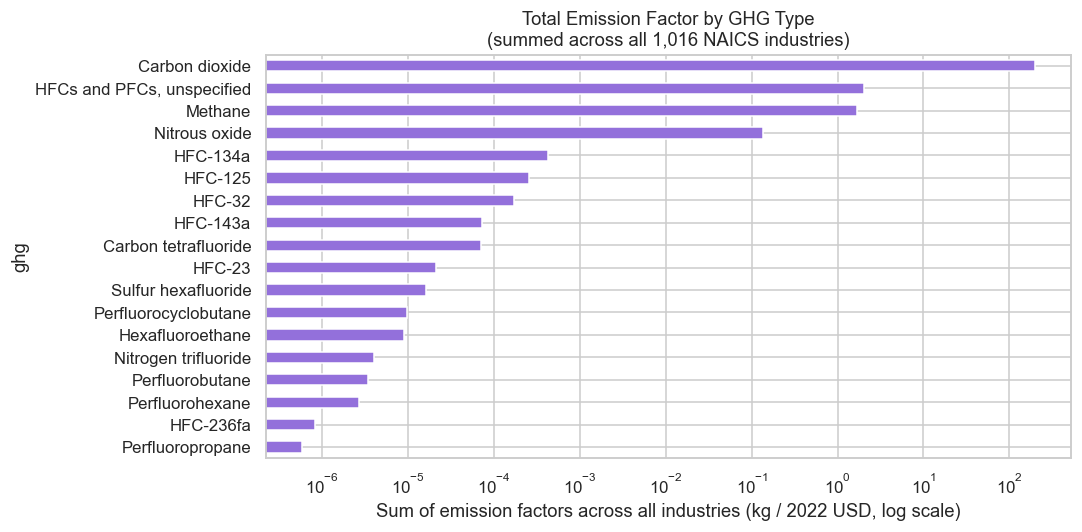

In [13]:
ghg_totals = (
    byghg.groupby("ghg")["ef_with_margin"]
    .sum()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 5))
ghg_totals[::-1].plot(kind="barh", ax=ax, color="mediumpurple", edgecolor="white")
ax.set_xscale("log")
ax.set_xlabel("Sum of emission factors across all industries (kg / 2022 USD, log scale)")
ax.set_title("Total Emission Factor by GHG Type\n(summed across all 1,016 NAICS industries)")
plt.tight_layout()
plt.show()


## 3. Key Takeaways

- The dataset covers **1,016 NAICS industries** at the 6-digit level — enough granularity for detailed sectoral analysis.
- Emission factors span **roughly two orders of magnitude** (~0.03 to ~4 kg CO2e/USD), with a heavily right-skewed distribution. A handful of agriculture- and energy-intensive industries are major outliers.
- The shift from 2021 → 2022 USD baselines **uniformly lowers** reported factors (because inflation means more dollars per unit of output). The two vintages are directly comparable after adjusting for the deflator.
- **Carbon dioxide and methane** dominate aggregate supply-chain emissions; the remaining 16 gases (HFCs, PFCs, etc.) are minor in aggregate but can be industry-significant.
- The by-GHG file opens up gas-specific analyses — for example, identifying which sectors are methane-dominated vs. CO2-dominated, relevant for different mitigation strategies.